# Predicting LendingClub Loan Charge-offs from Initial Listing Data


**June 14, 2018**

In [361]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Table of Contents

* [1. Introduction](#1)
 * [1.1 References](#1.1)
* [2. Import the Data](#2)
* [3. Response Variable](#3)
* [4. Limit the Feature Space](#4)
 * [4.1 Drop features missing more than 30% data](#4.1)
 * [4.2 Only keep loan features known to potential investors](#4.2)
* [5. Pre-processing and Exploratory Analysis](#5)
* [6. More Pre-processing](#6)
 * [6.1 Convert loan status to 0/1 charge-off indicator](#6.1)
 * [6.2 Create dummy variables](#6.2)
 * [6.3 Train/test split](#6.3)
* [7. Linear Dependence of Charge-off on the Predictors](#7)
* [8. Model Training and Testing](#8)
 * [8.1 Logistic regression with SGD training](#8.1)
 * [8.2 Random forest classifier](#8.2)
 * [8.3 k-nearest neighbors](#8.3)
 * [8.4 Tune hyperparameters on the chosen model more finely](#8.4)
 * [8.5 Test set evaluation](#8.5)
* [9. Conclusion](#9)

* There are new powerful machine learning models:
 1 CatBoost 2 XGBoost, 3 LightGBM

# 1. Introduction
<a id="1"></a>

[LendingClub](https://www.lendingclub.com/) is a US peer-to-peer lending company and the world's largest peer-to-peer lending platform. As explained by [Wikipedia](https://en.wikipedia.org/wiki/Lending_Club),

> Lending Club enables borrowers to create unsecured personal loans between \$1,000 and \$40,000. The standard loan period is three years. Investors can search and browse the loan listings on Lending Club website and select loans that they want to invest in based on the information supplied about the borrower, amount of loan, loan grade, and loan purpose. Investors make money from interest. Lending Club makes money by charging borrowers an origination fee and investors a service fee.

The goal of this project is to build a machine learning model to predict the probability that a loan will charge off. We will attempt to only use data available to investors via the LendingClub loan listing, including information about the borrower (income, employment length, FICO score, debt-to-income ratio, etc.) and the loan listing (the loan amount, loan purpose, loan grade, interest rate, installment, etc.). Such a predictive model could help LendingClub investors make better-informed investment decisions. We will only consider loans that LendingClub accepted under its credit underwriting policy.

## 1.1 References
<a id="1.1"></a>

* LendingClub information
 * [LendingClub website](https://www.lendingclub.com/)
 * [LendingClub Wikipedia page](https://en.wikipedia.org/wiki/Lending_Club)
* Datasets
 * [LendingClub statistics](https://www.lendingclub.com/info/download-data.action) - Original data source, aggregated on Kaggle
 * [All Lending Club loan data](https://www.kaggle.com/wordsforthewise/lending-club) - The dataset used in this project, hosted on Kaggle
 * [Lending Club Loan Data](https://www.kaggle.com/wendykan/lending-club-loan-data) - Another LendingClub dataset on Kaggle, not used in this project


# 2. Import the Data
<a id="2"></a>

In [362]:
import numpy as np
import seaborn
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas options
pd.set_option('display.max_colwidth', 1000, 'display.max_rows', None, 'display.max_columns', None)

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")


Read the data into a pandas dataframe:

In [363]:
loans = pd.read_csv('/content/drive/MyDrive/SP26-MGMT635852/200000.csv',nrows=10000)


In [364]:
loans.shape

(10000, 151)

Check basic dataframe info:

In [365]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 151 entries, id to settlement_term
dtypes: float64(115), int64(1), object(35)
memory usage: 11.5+ MB


For the complete dataset, there are 1.6 million rows and 150 variables. The size of the dataset is 1.8 GB.

Let's peek at 5 randomly selected rows. Each row corresponds to a single loan.

In [366]:
smallerSample= loans.sample(1000)

In [367]:
help(loans.sample)

Help on method sample in module pandas.core.generic:

sample(n: 'int | None' = None, frac: 'float | None' = None, replace: 'bool_t' = False, weights=None, random_state: 'RandomState | None' = None, axis: 'Axis | None' = None, ignore_index: 'bool_t' = False) -> 'Self' method of pandas.core.frame.DataFrame instance
    Return a random sample of items from an axis of object.

    You can use `random_state` for reproducibility.

    Parameters
    ----------
    n : int, optional
        Number of items from axis to return. Cannot be used with `frac`.
        Default = 1 if `frac` = None.
    frac : float, optional
        Fraction of axis items to return. Cannot be used with `n`.
    replace : bool, default False
        Allow or disallow sampling of the same row more than once.
    weights : str or ndarray-like, optional
        Default 'None' results in equal probability weighting.
        If passed a Series, will align with target object on index. Index
        values in weights not fo

In [368]:
smallerSample.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 2644 to 8702
Columns: 151 entries, id to settlement_term
dtypes: float64(115), int64(1), object(35)
memory usage: 1.2+ MB


In [369]:
smallerSample['desc']

,desc
2644,NaN
7918,NaN
36,NaN
4990,NaN
5494,NaN
8298,NaN
1133,NaN
1022,NaN
1120,NaN
8717,NaN


# 3. Response Variable
<a id="3"></a>

We're going to try to predict the `loan_status` variable. What are the value counts for this variable?

In [370]:
loans['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,6659
Current,1732
Charged Off,1431
Late (31-120 days),100
In Grace Period,53
Late (16-30 days),25


We're going to try to learn differences in the features between completed loans that have been fully paid or charged off. We won't consider loans that are current, don't meet the credit policy, defaulted, or have a missing status. So we only keep the loans with status "Fully Paid" or "Charged Off."

In [371]:
loans = loans.loc[loans['loan_status'].isin(['Fully Paid', 'Charged Off'])]

How many loans remain in the dataset?

In [372]:
loans.shape

(8090, 151)

There are 175421 loans remaining. Check that the statuses are as expected:

In [373]:
loans['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,6659
Charged Off,1431


Status counts as percentages:

In [374]:
loans['loan_status'].value_counts(normalize=True, dropna=False)

,proportion
loan_status,
Fully Paid,0.823115
Charged Off,0.176885


About 79% of the remaining loans have been fully paid and 20% have charged off, so we have a somewhat unbalanced classification problem.

# 4. Limit the Feature Space
<a id="4"></a>

The full dataset has 150 features for each loan. We'll select features in two steps:

1. Drop features with more than 30% of their data missing.
2. Of the remaining features, choose only those that would be available to an investor before deciding to fund the loan.

Definitions of the features are given in the LendingClub Data Dictionary [available here](https://www.lendingclub.com/info/download-data.action).

## 4.1 Drop features missing more than 30% data
<a id="4.1"></a>

First calculate the percentage of missing data for each feature:

In [375]:
missing_fractions = loans.isnull().mean().sort_values(ascending=False)


In [376]:
 missing_fractions

,0
member_id,1.000000
sec_app_num_rev_accts,1.000000
sec_app_open_act_il,1.000000
sec_app_mort_acc,1.000000
sec_app_inq_last_6mths,1.000000
dti_joint,1.000000
open_rv_24m,1.000000
total_cu_tl,1.000000
annual_inc_joint,1.000000
verification_status_joint,1.000000


Top 10 features missing the most data:

In [377]:
len(missing_fractions)

151

Let's visualize the distribution of missing data percentages:

Text(0, 0.5, 'Feature count')

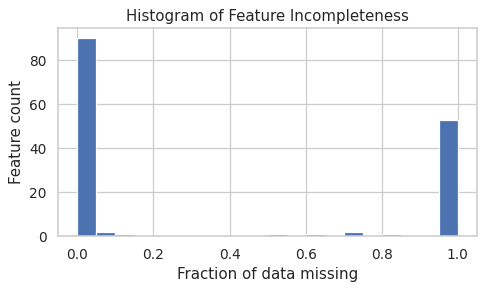

In [378]:
plt.figure(figsize=(6,3), dpi=90)
missing_fractions.plot.hist(bins=20)
plt.title('Histogram of Feature Incompleteness')
plt.xlabel('Fraction of data missing')
plt.ylabel('Feature count')

From the above histogram, we see there's a large gap between features missing "some" data (&lt;20%) and those missing "lots" of data (&gt;40%). Because it's generally very difficult to accurately impute data with more than 30% missing values, we drop such columns. First store all variables missing more than 30% data in an alphabetical list:

In [379]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_ma

How many features will be dropped?

In [380]:
len(drop_list)

58

Drop these features:

In [381]:
loans.drop(labels=drop_list, axis=1, inplace=True)

In [382]:
loans.shape

(8090, 93)

## 4.2 Only keep loan features known to potential investors
<a id="4.2"></a>

We examine the LendingClub website and Data Dictionary to determine which features would have been available to potential investors. Here's the list of features we currently have, in alphabetical order:

In [383]:
print(sorted(loans.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'loan_status', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sa

For each of these features, we check the description in the Data Dictionary and only keep the features that would have been available to investors considering an investment in the loan. These include features in the loan application, and any features added by LendingClub when the loan listing was accepted, such as the loan grade and interest rate.

I'm using my best available knowledge to determine which loan features are known to potential investors. I am not an investor on LendingClub, so my knowledge of the LendingClub investment process is not exact. When in doubt, I err on the side of dropping the feature.

In [384]:
keep_list = ['addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'issue_d', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code']

In [385]:
len(keep_list)

31

The list of features to drop is any feature not in `keep_list`:

In [386]:
drop_list = [col for col in loans.columns if col not in keep_list]
print(drop_list)

['funded_amnt', 'funded_amnt_inv', 'pymnt_plan', 'url', 'delinq_2yrs', 'inq_last_6mths', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc

In [387]:
len(drop_list)

62

Drop these features:

In [388]:
loans.drop(labels=drop_list, axis=1, inplace=True)

In [389]:
loans.shape

(8090, 31)

# 5. Data Understanding and Exploratory Analysis
<a id="5"></a>

We'll inspect each feature individually, and do the following:

1. Drop the feature if it is not useful for predicting the loan status.
2. View summary statistics and visualize the data, plotting against the loan status.
3. Modify the feature to make it useful for modeling, if necessary.

We define a function for plotting a variable and comparing with the loan status:

In [390]:
def plot_var(col_name, full_name, continuous):
    """
    Visualize a variable with and without faceting on the loan status.
    - col_name is the variable name in the dataframe
    - full_name is the full variable name
    - continuous is True if the variable is continuous, False otherwise
    """
    f, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,3), dpi=90)

    # Plot without loan status
    if continuous:
        sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)
    else:
        sns.countplot(x=loans[col_name], order=sorted(loans[col_name].unique()), color='#5975A4', saturation=1, ax=ax1)
    ax1.set_xlabel(full_name)
    ax1.set_ylabel('Count')
    ax1.set_title(full_name)

    # Plot with loan status
    if continuous:
        sns.boxplot(x=col_name, y='loan_status', data=loans, ax=ax2)
        ax2.set_ylabel('')
        ax2.set_title(full_name + ' by Loan Status')
    else:
        charge_off_rates = loans.groupby(col_name)['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']
        sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1, ax=ax2)
        ax2.set_ylabel('Fraction of Loans Charged-off')
        ax2.set_title('Charge-off Rate by ' + full_name)
    ax2.set_xlabel(full_name)
    plt.tight_layout()

Print the remaining features for future reference:

In [391]:
print(list(loans.columns))

['id', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies']


## 5.1 id

Data Dictionary: "A unique [LendingClub] assigned ID for the loan listing."

In [392]:
loans.head(5)

,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,zip_code,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies
0,38098114,15000.0,60 months,12.39,336.64,C,C1,MANAGEMENT,10+ years,RENT,78000.0,Source Verified,Dec-2014,Fully Paid,debt_consolidation,Debt consolidation,235xx,VA,12.03,Aug-1994,750.0,754.0,6.0,0.0,138008.0,29.0,17.0,w,Individual,0.0,0.0
1,36805548,10400.0,36 months,6.99,321.08,A,A3,Truck Driver Delivery Personel,8 years,MORTGAGE,58000.0,Not Verified,Dec-2014,Charged Off,credit_card,Credit card refinancing,937xx,CA,14.92,Sep-1989,710.0,714.0,17.0,0.0,6133.0,31.6,36.0,w,Individual,1.0,0.0
2,37842129,21425.0,60 months,15.59,516.36,D,D1,Programming Analysis Supervisor,6 years,RENT,63800.0,Source Verified,Dec-2014,Fully Paid,credit_card,Credit card refinancing,658xx,MO,18.49,Aug-2003,685.0,689.0,10.0,0.0,16374.0,76.2,35.0,w,Individual,0.0,0.0
4,37662224,7650.0,36 months,13.66,260.20,C,C3,Technical Specialist,< 1 year,RENT,50000.0,Source Verified,Dec-2014,Charged Off,debt_consolidation,Debt consolidation,850xx,AZ,34.81,Aug-2002,685.0,689.0,11.0,0.0,16822.0,91.9,20.0,f,Individual,0.0,0.0
5,37822187,9600.0,36 months,13.66,326.53,C,C3,Admin Specialist,10+ years,RENT,69000.0,Source Verified,Dec-2014,Fully Paid,debt_consolidation,Debt consolidation,077xx,NJ,25.81,Nov-1992,680.0,684.0,12.0,0.0,16388.0,59.4,44.0,f,Individual,0.0,0.0


In [393]:
loans['id'].sample(5)

,id
4529,36880308
7810,36300773
7481,36260968
9291,35853780
3334,37287644


Are all the IDs unique?

In [394]:
loans['id'].describe()

,id
count,8.090000e+03
mean,3.649136e+07
std,2.388153e+06
min,3.003900e+05
25%,3.624072e+07
50%,3.650035e+07
75%,3.726771e+07
max,3.809811e+07


Yes, they are all unique. The ID is not useful for modeling, either as a categorical variable (there are too many distinct values) or as a numerical variable (the IDs vary wildly in magnitude, likely without any significance), so we drop this variable.

In [395]:
loans.drop('id', axis=1, inplace=True)

## 5.2 loan_amnt

Data Dictionary: "The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value."

In [396]:
loans['loan_amnt'].head()

,loan_amnt
0,15000.0
1,10400.0
2,21425.0
4,7650.0
5,9600.0


In [397]:
loans['loan_amnt'].describe()

,loan_amnt
count,8090.000000
mean,14159.975278
std,8731.243172
min,1000.000000
25%,7200.000000
50%,12000.000000
75%,20000.000000
max,35000.000000


Loan amounts range from \$500 to \$40,000, with a median of \$12,000.

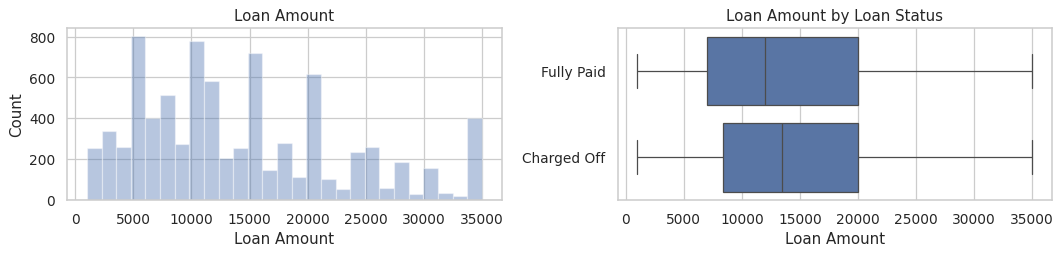

In [398]:
plot_var('loan_amnt', 'Loan Amount', continuous=True)

Charged-off loans tend to have higher loan amounts. Let's compare the summary statistics by loan status:

In [399]:
loans.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,15071.960168,8641.663462,1000.0,8400.0,13450.0,20000.0,35000.0
Fully Paid,6659.0,13963.992341,8738.600248,1000.0,7000.0,12000.0,20000.0,35000.0


## 5.3 term

Data Dictionary: "The number of payments on the loan. Values are in months and can be either 36 or 60."

In [400]:
loans['term'].value_counts(dropna=False)

,count
term,
36 months,6325
60 months,1765


In [401]:
loans['term'].head()

,term
0,60 months
1,36 months
2,60 months
4,36 months
5,36 months


Convert `term` to integers.

In [402]:
import numpy as np

loans['term'] = loans['term'].apply(lambda s: np.int8(s.split()[0]))

In [403]:
loans['term'].value_counts(normalize=True)

,proportion
term,
36,0.781829
60,0.218171


Compare the charge-off rate by loan period:

In [404]:
loans.groupby('term')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

,proportion
term,
36,0.134704
60,0.328045


About 76% of the completed loans have three-year periods, and the rest have five-year periods. Loans with five-year periods are more than twice as likely to charge-off as loans with three-year periods.

## 5.4 int_rate  Step for Data Understanding .


Data Dictionary: "Interest Rate on the loan."

In [405]:
loans['int_rate'].describe()

,int_rate
count,8090.000000
mean,12.349377
std,4.294257
min,6.000000
25%,8.670000
50%,11.990000
75%,14.990000
max,26.060000


Interest rates range from 5.32% to 30.99% (!) with a median of 13.1%.

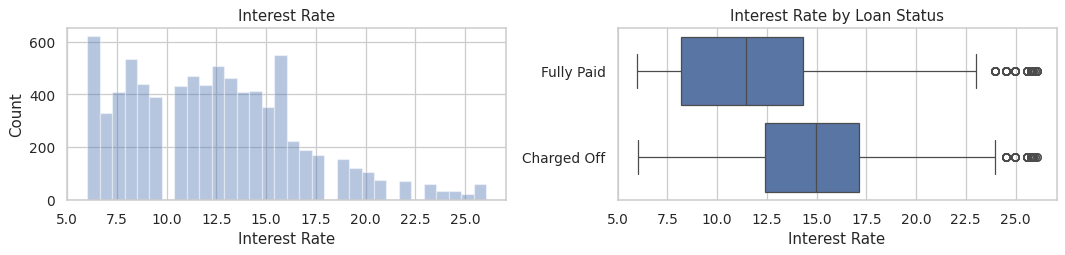

In [406]:
plot_var('int_rate', 'Interest Rate', continuous=True)

Charged-off loans tend to have much higher interest rates. Let's compare the summary statistics by loan status:

In [407]:
loans.groupby('loan_status')['int_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,15.020307,4.345991,6.03,12.39,14.99,17.14,26.06
Fully Paid,6659.0,11.775402,4.060127,6.00,8.19,11.44,14.31,26.06


## 5.5 installment

Data Dictionary: "The monthly payment owed by the borrower if the loan originates."

In [408]:
loans['installment'].describe()

,installment
count,8090.000000
mean,426.759646
std,258.650482
min,31.430000
25%,235.967500
50%,368.330000
75%,568.037500
max,1336.490000


Installments range from \$4.93 to \$1,714, with a median of \$377.

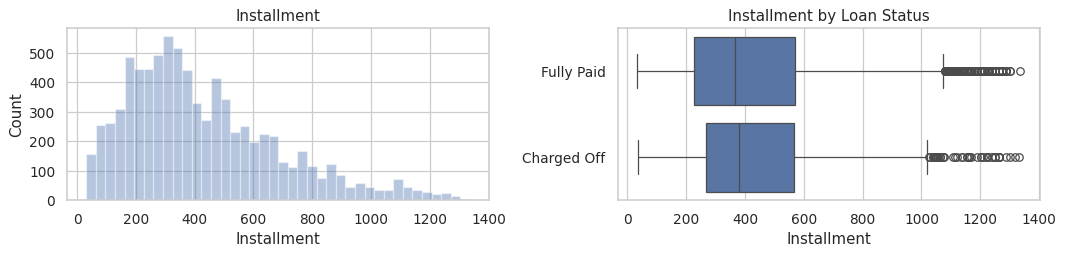

In [409]:
plot_var('installment', 'Installment', continuous=True)

Charged-off loans tend to have higher installments. Let's compare the summary statistics by loan status:

In [410]:
loans.groupby('loan_status')['installment'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,441.469553,249.845378,34.67,266.465,377.79,567.105,1331.78
Fully Paid,6659.0,423.598530,260.413638,31.43,227.485,367.34,568.700,1336.49


Loans that charge off have \$30 higher installments on average.

## 5.6 grade, sub_grade

Data Dictionary for `grade`: "LendingClub assigned loan grade."

Data Dictionary for `sub_grade`: "LendingClub assigned loan subgrade."

What are the possible values of `grade` and `sub_grade`?

In [411]:
print(sorted(loans['grade'].unique()))

['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [412]:
print(sorted(loans['sub_grade'].unique()))

['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


The grade is implied by the subgrade, so let's drop the grade column.

In [413]:
loans.drop('grade', axis=1, inplace=True)

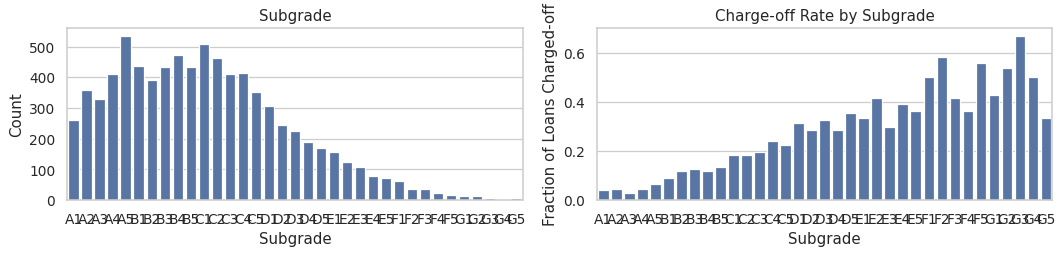

In [414]:
plot_var('sub_grade', 'Subgrade', continuous=False)

There's a clear trend of higher probability of charge-off as the subgrade worsens.

## 5.7 emp_title

Data Dictionary: "The job title supplied by the Borrower when applying for the loan."

In [415]:
loans['emp_title'].describe()

,emp_title
count,7679
unique,4536
top,Teacher
freq,165


There are too many different job titles for this feature to be useful, so we drop it.

In [416]:
loans.drop(labels='emp_title', axis=1, inplace=True)

## 5.8 emp_length

Data Dictionary: "Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years." The actual data does not match this description:

In [417]:
loans['emp_length'].value_counts(dropna=False).sort_index()

,count
emp_length,
1 year,540
10+ years,2584
2 years,721
3 years,659
4 years,495
5 years,474
6 years,394
7 years,413
8 years,377


In [418]:
loans['emp_length'].head(100)

,emp_length
0,10+ years
1,8 years
2,6 years
4,< 1 year
5,10+ years
6,< 1 year
7,6 years
8,10+ years
9,2 years
10,8 years


Note there are 42,253 loans without data on the length of employment.

Convert `emp_length` to integers:

In [419]:
loans['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)

In [420]:
loans['emp_length'].replace('< 1 year', '0 years', inplace=True)

In [421]:
def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])

In [422]:
loans['emp_length'] = loans['emp_length'].apply(emp_length_to_int)

In [423]:
loans['emp_length'].value_counts(dropna=False).sort_index()

,count
emp_length,
0.0,725
1.0,540
2.0,721
3.0,659
4.0,495
5.0,474
6.0,394
7.0,413
8.0,377


In [424]:
help(plot_var)

Help on function plot_var in module __main__:

plot_var(col_name, full_name, continuous)
    Visualize a variable with and without faceting on the loan status.
    - col_name is the variable name in the dataframe
    - full_name is the full variable name
    - continuous is True if the variable is continuous, False otherwise



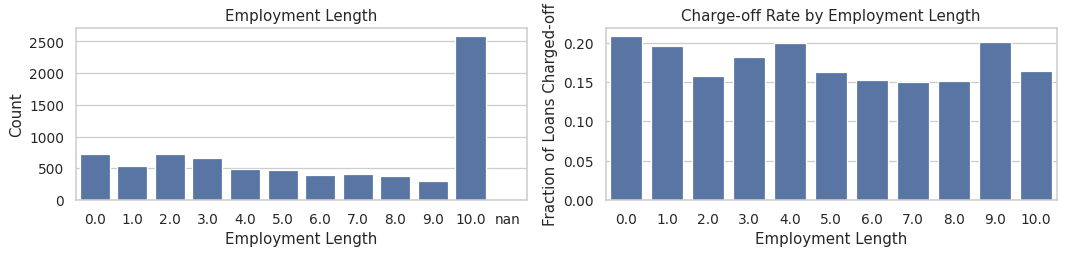

In [425]:
plot_var('emp_length', 'Employment Length', continuous=False)

Loan status does not appear to vary much with employment length on average, except for a small drop in charge-offs for borrowers with over 10 years of employment.

## 5.9 home_ownership

Data Dictionary: "The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER."

In [426]:
loans['home_ownership'].value_counts(dropna=False)

,count
home_ownership,
MORTGAGE,3949
RENT,3255
OWN,886


Replace the values `ANY` and `NONE` with `OTHER`:

In [427]:
loans['home_ownership'].replace(['NONE', 'ANY'], 'OTHER', inplace=True)

In [428]:
loans['home_ownership'].value_counts(dropna=False)

,count
home_ownership,
MORTGAGE,3949
RENT,3255
OWN,886


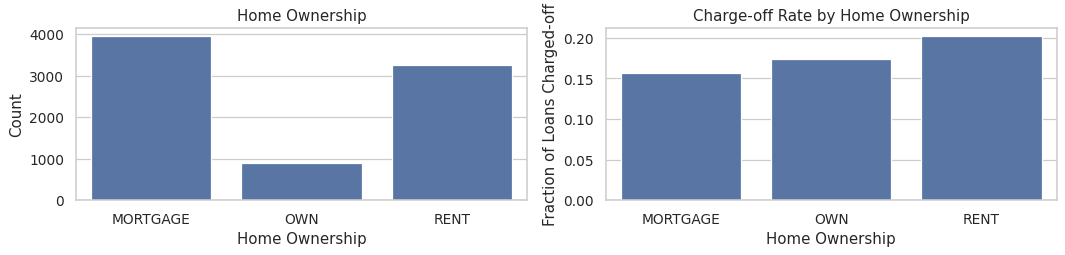

In [429]:
plot_var('home_ownership', 'Home Ownership', continuous=False)

There appear to be large differences in charge-off rates by home ownership status. Renters and homeowners have a higher probability of charge-off. Let's compare the charge-off rates:

In [430]:
loans.groupby('home_ownership')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

,proportion
home_ownership,
MORTGAGE,0.156749
OWN,0.173815
RENT,0.202151


## 5.10 annual_inc

Data Dictionary: "The self-reported annual income provided by the borrower during registration."

In [431]:
loans['annual_inc'].describe()

,annual_inc
count,8.090000e+03
mean,7.730487e+04
std,5.547272e+04
min,7.000000e+03
25%,4.500750e+04
50%,6.500000e+04
75%,9.200000e+04
max,1.100000e+06


Annual income ranges from \$0 to \$9,550,000, with a median of \$65,000. Because of the large range of incomes, we should take a log transform of the annual income variable.

In [432]:
loans['log_annual_inc'] = loans['annual_inc'].apply(lambda x: np.log10(x+1))

In [433]:
loans.drop('annual_inc', axis=1, inplace=True)

In [434]:
loans['log_annual_inc'].describe()

,log_annual_inc
count,8090.000000
mean,4.816658
std,0.241097
min,3.845160
25%,4.653295
50%,4.812920
75%,4.963793
max,6.041393


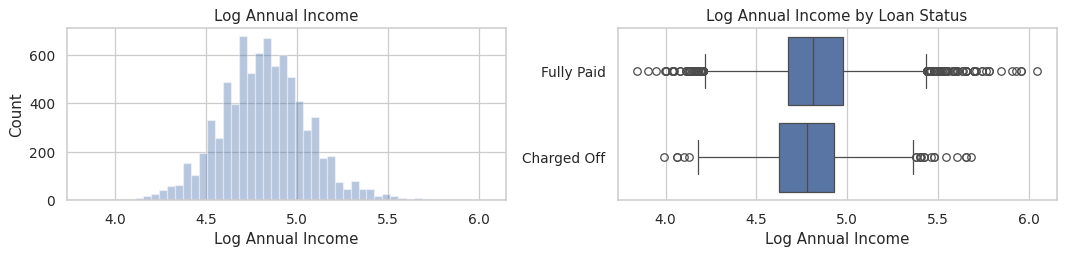

In [435]:
plot_var('log_annual_inc', 'Log Annual Income', continuous=True)

It appears that individuals with higher income are more likely to pay off their loans. Let's compare the summary statistics by loan status:

In [436]:
loans.groupby('loan_status')['log_annual_inc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,4.778784,0.232657,3.989049,4.623260,4.778158,4.924284,5.681242
Fully Paid,6659.0,4.824797,0.242117,3.845160,4.672107,4.812920,4.977271,6.041393


## 5.11 verification_status

Data Dictionary: "Indicates if income was verified by [Lending Club], not verified, or if the income source was verified."

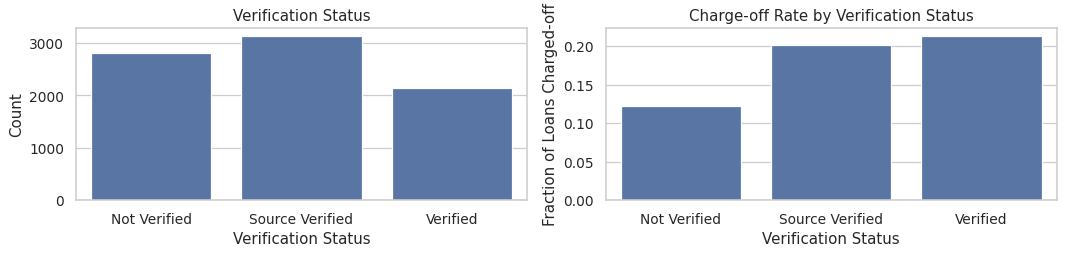

In [437]:
plot_var('verification_status', 'Verification Status', continuous=False)

## 5.12 issue_d

Data Dictionary: "The month which the loan was funded."

Because we're only using variables available to investors before the loan was funded, `issue_d` will not be included in the final model. We're keeping it for now just to perform the train/test split later, then we'll drop it.

## 5.13 purpose

Data Dictionary: "A category provided by the borrower for the loan request."

In [438]:
loans['purpose'].value_counts()

,count
purpose,
debt_consolidation,4713
credit_card,1778
other,522
home_improvement,466
major_purchase,195
medical,105
car,80
small_business,78
vacation,60


Calculate the charge-off rates by purpose:

In [439]:
loans.groupby('purpose')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off'].sort_values()

,proportion
purpose,
car,0.037500
vacation,0.100000
medical,0.133333
home_improvement,0.150215
credit_card,0.151856
other,0.183908
debt_consolidation,0.187778
moving,0.203704
major_purchase,0.230769


Notice that only 12% of completed loans for weddings have charged-off, but 30% of completed small business loans have charged-off.

## 5.14 title

Data Dictionary: "The loan title provided by the borrower."

In [440]:
loans['title'].describe()

,title
count,8090
unique,12
top,Debt consolidation
freq,4709


View the top 10 loan titles, and their frequencies:

In [441]:
loans['title'].value_counts().head(10)

,count
title,
Debt consolidation,4709
Credit card refinancing,1779
Other,521
Home improvement,471
Major purchase,196
Medical expenses,105
Car financing,79
Business,78
Vacation,59


There are 60,298 different titles in the dataset, and based on the top 10 titles, the `purpose` variable appears to already contain this information. So we drop the `title` variable.

In [442]:
loans.drop('title', axis=1, inplace=True)

## 5.15 zip_code, addr_state

Data Dictionary for `zip_code`: "The first 3 numbers of the zip code provided by the borrower in the loan application."

Data Dictionary for `addr_state`: "The state provided by the borrower in the loan application."

In [443]:
loans['zip_code'].sample(5)

,zip_code
2426,014xx
6681,480xx
2842,917xx
4855,072xx
6155,925xx


In [444]:
loans['zip_code'].nunique()

749

In [445]:
loans['addr_state'].sample(5)

,addr_state
4845,CA
1374,CA
7089,WI
9687,TX
8729,OK


In [446]:
loans['addr_state'].nunique()

46

There are a lot of different zip codes, so let's just keep the state column.

In [447]:
loans.drop(labels='zip_code', axis=1, inplace=True)

Calculate the charge-off rates by address state:

In [448]:
loans.groupby('addr_state')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off'].sort_values()

,proportion
addr_state,
NH,0.032258
MT,0.038462
AK,0.045455
SD,0.055556
KS,0.075472
KY,0.088608
WV,0.090909
OR,0.093750
UT,0.120690


The charge-off rate ranges from 13.0% in Washington, DC to 27.6% in Mississippi.

## 5.16 dti

Data Dictionary: "A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income."

In [449]:
loans['dti'].describe()

,dti
count,8090.00000
mean,17.87757
std,8.51233
min,0.00000
25%,11.42250
50%,17.23000
75%,23.67000
max,39.96000


Note sure if the values of -1 and 999 make sense...

There are several outliers that mess up our default plots. Plot a histogram for `dti` less than 60:

Text(0.5, 1.0, 'Debt-to-income Ratio')

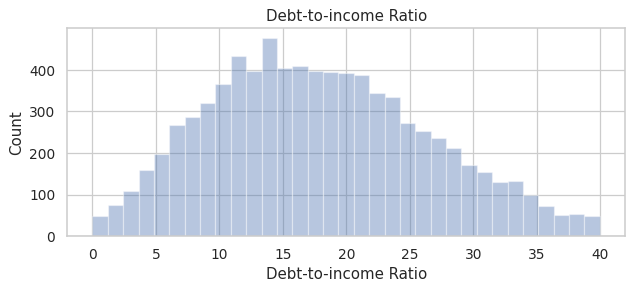

In [450]:
plt.figure(figsize=(8,3), dpi=90)
sns.distplot(loans.loc[loans['dti'].notnull() & (loans['dti']<60), 'dti'], kde=False)
plt.xlabel('Debt-to-income Ratio')
plt.ylabel('Count')
plt.title('Debt-to-income Ratio')

How many of the `dti` values are "outliers" (above 60)?

In [451]:
(loans['dti']>=60).sum()

np.int64(0)

Very few. Compare the summary statistics by loan status:

In [452]:
loans.groupby('loan_status')['dti'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,20.044186,8.583499,0.0,13.525,19.56,26.00,39.95
Fully Paid,6659.0,17.411970,8.425175,0.0,11.040,16.67,23.15,39.96


Completed loans that are charged off tend to have higher debt-to-income ratios.

## 5.17 earliest_cr_line

Data Dictionary: "The month the borrower's earliest reported credit line was opened."

In [453]:
loans['earliest_cr_line'].sample(5)

,earliest_cr_line
1901,May-1994
6894,Apr-2000
76,Aug-2006
4674,Dec-1998
1161,Jul-1985


In [454]:
loans['earliest_cr_line'].isnull().any()

np.False_

Let's just retain the year for simplicity:

In [455]:
loans['earliest_cr_line'] = loans['earliest_cr_line'].apply(lambda s: int(s[-4:]))

In [456]:
loans['earliest_cr_line'].describe()

,earliest_cr_line
count,8090.000000
mean,1997.888504
std,7.717165
min,1958.000000
25%,1994.000000
50%,1999.000000
75%,2003.000000
max,2011.000000


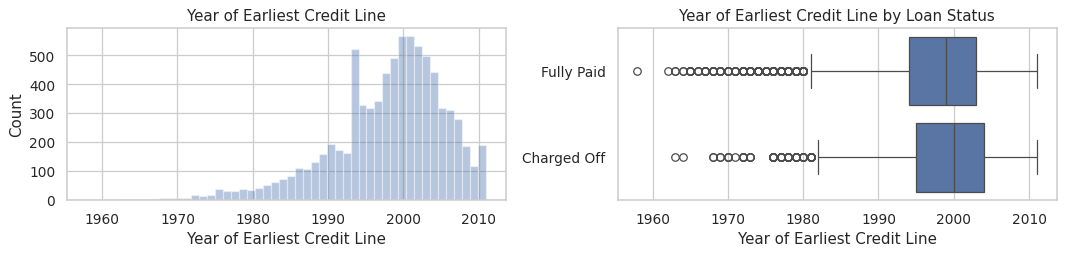

In [457]:
plot_var('earliest_cr_line', 'Year of Earliest Credit Line', continuous=True)

Borrowers who are charged-off tend to have shorter lines of credit.

## 5.18 fico_range_low, fico_range_high

Data Dictionary for `fico_range_low`: "The lower boundary range the borrower’s FICO at loan origination belongs to."

Data Dictionary for `fico_range_high`: "The upper boundary range the borrower’s FICO at loan origination belongs to."

In [458]:
loans[['fico_range_low', 'fico_range_high']].describe()

,fico_range_low,fico_range_high
count,8090.000000,8090.000000
mean,696.596415,700.596539
std,31.828147,31.828725
min,660.000000,664.000000
25%,670.000000,674.000000
50%,690.000000,694.000000
75%,710.000000,714.000000
max,845.000000,850.000000


Check the Pearson correlation between these values:

In [459]:
loans[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


In [460]:
loans[['fico_range_low', 'fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


In [461]:
loans.head()

,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,log_annual_inc
0,15000.0,60,12.39,336.64,C1,10.0,RENT,Source Verified,Dec-2014,Fully Paid,debt_consolidation,VA,12.03,1994,750.0,754.0,6.0,0.0,138008.0,29.0,17.0,w,Individual,0.0,0.0,4.892100
1,10400.0,36,6.99,321.08,A3,8.0,MORTGAGE,Not Verified,Dec-2014,Charged Off,credit_card,CA,14.92,1989,710.0,714.0,17.0,0.0,6133.0,31.6,36.0,w,Individual,1.0,0.0,4.763435
2,21425.0,60,15.59,516.36,D1,6.0,RENT,Source Verified,Dec-2014,Fully Paid,credit_card,MO,18.49,2003,685.0,689.0,10.0,0.0,16374.0,76.2,35.0,w,Individual,0.0,0.0,4.804827
4,7650.0,36,13.66,260.20,C3,0.0,RENT,Source Verified,Dec-2014,Charged Off,debt_consolidation,AZ,34.81,2002,685.0,689.0,11.0,0.0,16822.0,91.9,20.0,f,Individual,0.0,0.0,4.698979
5,9600.0,36,13.66,326.53,C3,10.0,RENT,Source Verified,Dec-2014,Fully Paid,debt_consolidation,NJ,25.81,1992,680.0,684.0,12.0,0.0,16388.0,59.4,44.0,f,Individual,0.0,0.0,4.838855


We only need to keep one of the FICO scores. We'll take the average of the two and call it `fico_score`:

In [462]:
loans['fico_score'] = 0.5*loans['fico_range_low'] + 0.5*loans['fico_range_high']

In [463]:
loans.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

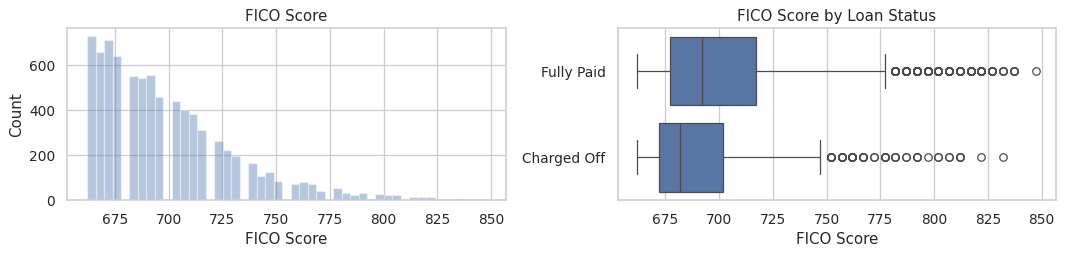

In [464]:
plot_var('fico_score', 'FICO Score', continuous=True)

There is a noticeable difference in FICO scores between fully paid and charged-off loans. Compare the summary statistics:

In [465]:
loans.groupby('loan_status')['fico_score'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,690.029350,26.204451,662.0,672.0,682.0,702.0,832.0
Fully Paid,6659.0,700.437528,32.621088,662.0,677.0,692.0,717.0,847.5


Loans that charge off have a FICO score 10 points lower on average.

## 5.19 open_acc

Data Dictionary: "The number of open credit lines in the borrower's credit file."

Text(0.5, 1.0, 'Number of Open Credit Lines')

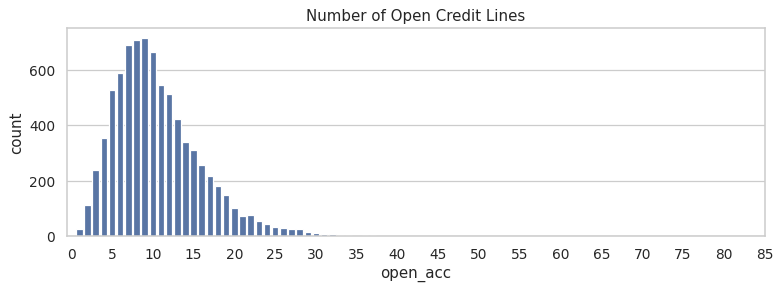

In [466]:
plt.figure(figsize=(10,3), dpi=90)
sns.countplot(x=loans['open_acc'], order=sorted(loans['open_acc'].unique()), color='#5975A4', saturation=1)
_, _ = plt.xticks(np.arange(0, 90, 5), np.arange(0, 90, 5))
plt.title('Number of Open Credit Lines')

Is there a difference in number of credit lines between fully paid loans and charged-off loans?

In [467]:
loans.groupby('loan_status')['open_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,12.051712,5.524527,1.0,8.0,11.0,15.0,53.0
Fully Paid,6659.0,11.500375,5.435616,2.0,8.0,11.0,14.0,54.0


## 5.20 pub_rec

Data Dictionary: "Number of derogatory public records."

In [468]:
loans['pub_rec'].value_counts().sort_index()

,count
pub_rec,
0.0,6832
1.0,1035
2.0,148
3.0,40
4.0,18
5.0,8
6.0,4
7.0,3
12.0,1


Is there a difference in average public records between fully paid loans and charged-off loans?

In [469]:
loans.groupby('loan_status')['pub_rec'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,0.229210,0.626244,0.0,0.0,0.0,0.0,6.0
Fully Paid,6659.0,0.196726,0.592875,0.0,0.0,0.0,0.0,18.0


## 5.21 revol_bal

Data Dictionary: "Total credit revolving balance."

In [470]:
loans['revol_bal'].describe()

,revol_bal
count,8.090000e+03
mean,1.855396e+04
std,3.079560e+04
min,0.000000e+00
25%,6.255750e+03
50%,1.182550e+04
75%,2.131650e+04
max,1.298783e+06


Do a log transform:

In [471]:
loans['log_revol_bal'] = loans['revol_bal'].apply(lambda x: np.log10(x+1))

In [472]:
loans.drop('revol_bal', axis=1, inplace=True)

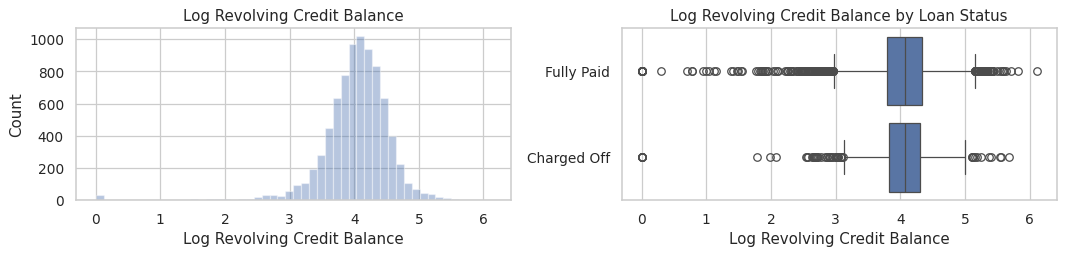

In [473]:
plot_var('log_revol_bal', 'Log Revolving Credit Balance', continuous=True)

In [474]:
loans.groupby('loan_status')['log_revol_bal'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,4.027236,0.486046,0.0,3.832892,4.072654,4.304714,5.685976
Fully Paid,6659.0,4.031644,0.531288,0.0,3.788628,4.072911,4.334343,6.113537


There isn't a large difference in the means.

## 5.22 revol_util

Data Dictionary: "Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit."

In [475]:
loans['revol_util'].describe()

,revol_util
count,8085.000000
mean,53.206790
std,24.408579
min,0.000000
25%,34.600000
50%,53.100000
75%,72.500000
max,134.300000


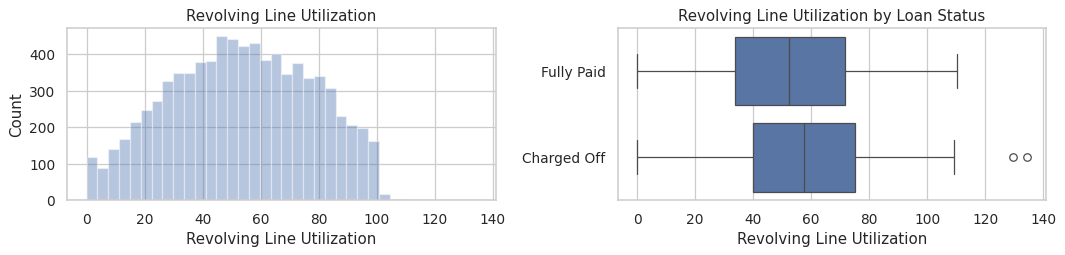

In [476]:
plot_var('revol_util', 'Revolving Line Utilization', continuous=True)

In [477]:
loans.groupby('loan_status')['revol_util'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1430.0,56.981189,23.843489,0.0,40.025,57.5,75.3,134.3
Fully Paid,6655.0,52.395763,24.454132,0.0,33.700,52.3,71.6,110.3


## 5.23 total_acc

Data Dictionary: "The total number of credit lines currently in the borrower's credit file."

Text(0.5, 1.0, 'Total Number of Credit Lines')

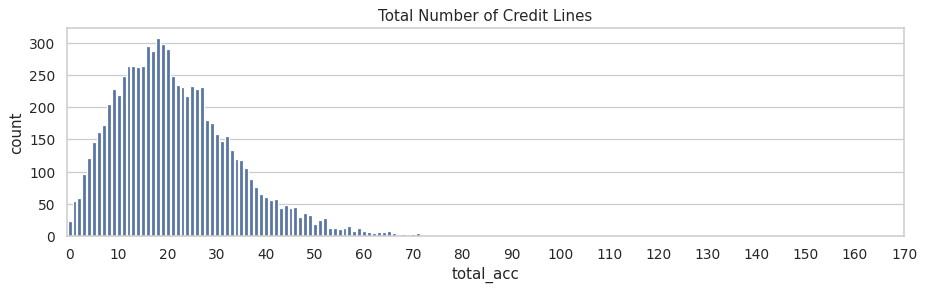

In [478]:
plt.figure(figsize=(12,3), dpi=90)
sns.countplot(x= loans['total_acc'], order=sorted(loans['total_acc'].unique()), color='#5975A4', saturation=1)

_, _ = plt.xticks(np.arange(0, 176, 10), np.arange(0, 176, 10))
plt.title('Total Number of Credit Lines')

In [479]:
loans.groupby('loan_status')['total_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,25.882600,12.378593,4.0,16.0,24.0,33.0,78.0
Fully Paid,6659.0,25.494969,12.316460,4.0,17.0,24.0,32.0,150.0


No large differences here.

## 5.24 initial_list_status

Data Dictionary: "The initial listing status of the loan. Possible values are – W, F." I'm not sure what this means.

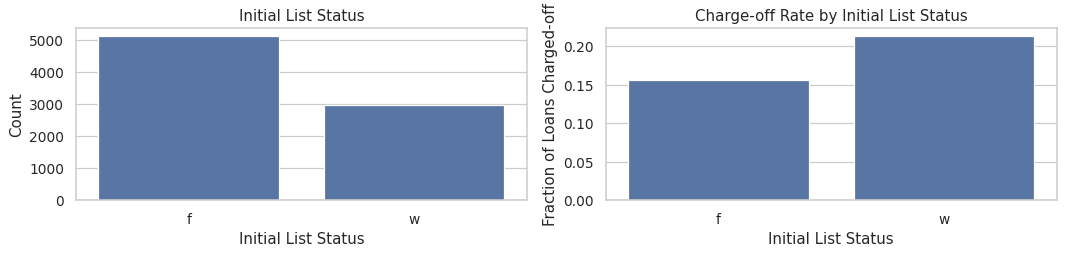

In [480]:
plot_var('initial_list_status', 'Initial List Status', continuous=False)

## 5.25 application_type

Data Dictionary: "Indicates whether the loan is an individual application or a joint application with two co-borrowers."

In [481]:
loans['application_type'].value_counts()

,count
application_type,
Individual,8090


Let's just compare the charge-off rates by application type:

In [482]:
loans.groupby('application_type')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

,proportion
application_type,
Individual,0.176885


Joint loans are slightly less likely to be charged-off.

## 5.26 mort_acc

Data Dictionary: "Number of mortgage accounts."

In [483]:
loans['mort_acc'].describe()

,mort_acc
count,8090.000000
mean,1.778492
std,2.113513
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,20.000000


Not sure how someone can have 51 mortgage accounts...but apparently they do. Check the top 10 values:

In [484]:
loans['mort_acc'].value_counts().head(10)

,count
mort_acc,
0.0,3242
1.0,1269
2.0,1178
3.0,886
4.0,599
5.0,399
6.0,242
7.0,127
8.0,70


Compare the summary statistics by loan status:

In [485]:
loans.groupby('loan_status')['mort_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,1431.0,1.531097,1.996915,0.0,0.0,1.0,3.0,13.0
Fully Paid,6659.0,1.831656,2.134142,0.0,0.0,1.0,3.0,20.0


Individuals who pay off their loans are more likely to have several mortgage accounts.

## 5.27 pub_rec_bankruptcies

Data Dictionary: "Number of public record bankruptcies."

In [486]:
loans['pub_rec_bankruptcies'].value_counts().sort_index()

,count
pub_rec_bankruptcies,
0.0,7217
1.0,824
2.0,37
3.0,8
4.0,2
5.0,1
7.0,1


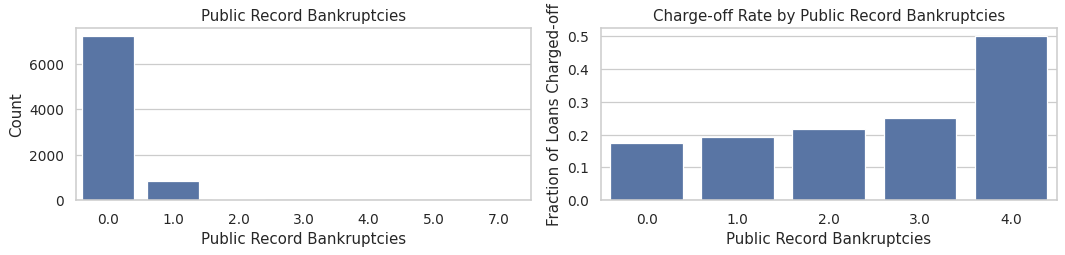

In [487]:
plot_var('pub_rec_bankruptcies', 'Public Record Bankruptcies', continuous=False)

# 6. More Pre-processing
<a id="6"></a>

## 6.1 Convert loan status to 0/1 charge-off indicator
<a id="6.1"></a>

Change the response variable `loan_status` to a 0/1 variable, where 0 indicates fully paid and 1 indicates charge-off:

In [488]:
loans['charged_off'] = (loans['loan_status'] == 'Charged Off').apply(np.uint8)
loans.drop('loan_status', axis=1, inplace=True)

## 6.2 Create dummy variables
<a id="6.2"></a>

How many variables do we currently have?

In [489]:
loans.shape

(8090, 25)

If any categorical variables have missing values, we'll need to create NaN dummy variables for those. So first check which variables have missing data:

In [490]:
missing_fractions = loans.isnull().mean().sort_values(ascending=False) # Fraction of data missing for each variable

In [491]:
print(missing_fractions[missing_fractions > 0]) # Print variables that are missing data

emp_length    0.050556
revol_util    0.000618
dtype: float64


There are no categorical variables with missing values, and therefore we don't need any `NaN` dummy variables.

Create dummy variables for the categorical variables:

In [492]:
print(loans.columns)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_length', 'home_ownership', 'verification_status', 'issue_d',
       'purpose', 'addr_state', 'dti', 'earliest_cr_line', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'initial_list_status',
       'application_type', 'mort_acc', 'pub_rec_bankruptcies',
       'log_annual_inc', 'fico_score', 'log_revol_bal', 'charged_off'],
      dtype='object')


In [493]:
loans = pd.get_dummies(loans, columns=['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type'], drop_first=True)

How many variables are there now?

In [494]:
loans.shape

(8090, 113)

Check our data with the new dummy variables:

In [495]:
loans.sample(5)

,loan_amnt,term,int_rate,installment,emp_length,issue_d,dti,earliest_cr_line,open_acc,pub_rec,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,log_annual_inc,fico_score,log_revol_bal,charged_off,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,addr_state_AL,addr_state_AR,addr_state_AZ,addr_state_CA,addr_state_CO,addr_state_CT,addr_state_DC,addr_state_DE,addr_state_FL,addr_state_GA,addr_state_HI,addr_state_IL,addr_state_IN,addr_state_KS,addr_state_KY,addr_state_LA,addr_state_MA,addr_state_MD,addr_state_MI,addr_state_MN,addr_state_MO,addr_state_MS,addr_state_MT,addr_state_NC,addr_state_NH,addr_state_NJ,addr_state_NM,addr_state_NV,addr_state_NY,addr_state_OH,addr_state_OK,addr_state_OR,addr_state_PA,addr_state_RI,addr_state_SC,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w
167,2000.0,36,15.59,69.91,10.0,Dec-2014,15.05,2000,10.0,0.0,79.4,17.0,1.0,0.0,4.845104,667.0,4.209569,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
7737,8000.0,36,11.44,263.58,8.0,Dec-2014,24.83,2001,4.0,0.0,54.6,26.0,0.0,0.0,4.459408,687.0,3.867232,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3131,15000.0,60,11.44,329.44,9.0,Dec-2014,26.45,1998,18.0,0.0,48.9,35.0,5.0,0.0,5.000004,722.0,4.259880,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
8234,12000.0,36,8.67,379.76,9.0,Dec-2014,16.49,1997,15.0,1.0,45.1,51.0,5.0,1.0,4.812920,667.0,3.909663,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,Fa

## 6.3 Train/test split
<a id="6.3"></a>

We'll make our modeling problem more realistic by performing the train/test split based on the month that the loan was funded. That is, we'll use loans funded on earlier dates to predict whether future loans will charge-off. The variable `issue_d` includes the month and year that the loan was funded.

In [496]:
loans['issue_d'].sample(5)

,issue_d
6879,Dec-2014
7041,Dec-2014
9327,Dec-2014
8948,Nov-2014
1162,Dec-2014


Are there any missing values?

In [497]:
loans['issue_d'].isnull().any()

np.False_

No. Let's convert the issue dates to datetime objects:

In [498]:
loans['issue_d'] = pd.to_datetime(loans['issue_d'])

In [499]:
loans['issue_d'].sample(5)

,issue_d
8703,2014-11-01
8888,2014-12-01
3552,2014-12-01
8444,2014-12-01
440,2014-12-01


The new datetime values are all on the first day of the month. Check the summary statistics of the issue dates:

In [500]:
loans['issue_d'].describe()

,issue_d
count,8090
mean,2014-11-28 20:01:28.998764032
min,2014-11-01 00:00:00
25%,2014-12-01 00:00:00
50%,2014-12-01 00:00:00
75%,2014-12-01 00:00:00
max,2014-12-01 00:00:00


There are only 124 unique issue dates over the 10-year period because we only have month/year information. In this particular dataset, the first loans were issued in June 2007, and the most recent loans were issued in September 2017. The busiest month was October 2014 with 33,699 loans funded in that month. What is the distribution of loans funded in each year?

Text(0.5, 1.0, 'Loans Funded per Year')

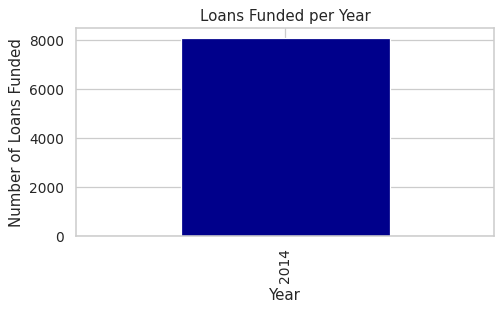

In [501]:
plt.figure(figsize=(6,3), dpi=90)
loans['issue_d'].dt.year.value_counts().sort_index().plot.bar(color='darkblue')
plt.xlabel('Year')
plt.ylabel('Number of Loans Funded')
plt.title('Loans Funded per Year')

We'll form the test set from the most recent 10% of the loans.

In [502]:
loans_train = loans.loc[loans['issue_d'] <  loans['issue_d'].quantile(0.9)]
loans_test =  loans.loc[loans['issue_d'] >= loans['issue_d'].quantile(0.9)]

In [503]:
loans_train.shape, loans_test.shape

((584, 113), (7506, 113))

Check that we properly partitioned the loans:

In [504]:
print('Number of loans in the partition:   ', loans_train.shape[0] + loans_test.shape[0])
print('Number of loans in the full dataset:', loans.shape[0])

Number of loans in the partition:    8090
Number of loans in the full dataset: 8090


What is the test size?

In [505]:
loans_test.shape[0] / loans.shape[0]

0.9278121137206428

The partition looks good, so we can delete the original `loans` dataframe:

In [506]:
del loans

Let's look at the summary statistics of the issue dates in the train and test sets:

In [507]:
loans_train['issue_d'].describe()

,issue_d
count,584
mean,2014-11-01 00:00:00
min,2014-11-01 00:00:00
25%,2014-11-01 00:00:00
50%,2014-11-01 00:00:00
75%,2014-11-01 00:00:00
max,2014-11-01 00:00:00


In [508]:
loans_test['issue_d'].describe()

,issue_d
count,7506
mean,2014-12-01 00:00:00.000000256
min,2014-12-01 00:00:00
25%,2014-12-01 00:00:00
50%,2014-12-01 00:00:00
75%,2014-12-01 00:00:00
max,2014-12-01 00:00:00


The training set includes loans from June 2007 to June 2016. The test set includes loans from July 2016 to September 2017.

Now we need to delete the `issue_d` variable, because it was not available before the loan was funded.

In [509]:
loans_train.drop('issue_d', axis=1, inplace=True)
loans_test.drop('issue_d', axis=1, inplace=True)

Now separate the predictor variables from the response variable:
Because the input dataset is really big,  I only take 10% DATA for training.  You can use 100% data.

In [510]:

subsetloans_train=loans_train.sample(frac=0.1)

#y_train = loans_train['charged_off']
y_train = subsetloans_train['charged_off']

y_test = loans_test['charged_off']

In [511]:
#X_train = loans_train.drop('charged_off', axis=1)
X_train = subsetloans_train.drop('charged_off', axis=1)
X_test = loans_test.drop('charged_off', axis=1)

In [512]:
del loans_train, loans_test

# 7. Linear Dependence of Charge-off on the Predictors
<a id="7"></a>

On the training set, we compute the Pearson correlation, F-statistics and $p$ value of each predictor with the response variable `charged_off`.

In [513]:
linear_dep = pd.DataFrame()

Pearson correlations:

In [514]:
for col in X_train.columns:
    linear_dep.loc[col, 'pearson_corr'] = X_train[col].corr(y_train)
linear_dep['abs_pearson_corr'] = abs(linear_dep['pearson_corr'])

$F$-statistics:

In [515]:
from sklearn.feature_selection import f_classif
for col in X_train.columns:
    mask = X_train[col].notnull()
    (linear_dep.loc[col, 'F'], linear_dep.loc[col, 'p_value']) = f_classif(pd.DataFrame(X_train.loc[mask, col]), y_train.loc[mask])

Sort the results by the absolute value of the Pearson correlation:

In [516]:
linear_dep.sort_values('abs_pearson_corr', ascending=False, inplace=True)
linear_dep.drop('abs_pearson_corr', axis=1, inplace=True)

Reset the index:

In [517]:
linear_dep.reset_index(inplace=True)
linear_dep.rename(columns={'index':'variable'}, inplace=True)

View the results for the top 20 predictors most correlated with `charged_off`:

In [518]:
linear_dep.head(100)

,variable,pearson_corr,F,p_value
0,term,0.623377,35.592803,1.726666e-07
1,int_rate,0.472259,16.074742,1.819615e-04
2,dti,0.345026,7.567249,7.991419e-03
3,loan_amnt,0.339331,7.287259,9.165227e-03
4,sub_grade_D5,0.335030,7.080460,1.014844e-02
5,verification_status_Verified,0.246753,3.630747,6.186021e-02
6,addr_state_MI,0.234814,3.267904,7.601951e-02
7,sub_grade_E5,0.234814,3.267904,7.601951e-02
8,addr_state_TN,0.234814,3.267904,7.601951e-02
9,sub_grade_C4,0.232113,3.188886,7.955553e-02


The variables most linearly correlated with `charged_off` are the interest rate, loan period (term), FICO score, debt-to-income ratio, number of mortgages, income, the loan grade, and the loan amount.

Now view the results for the 20 least correlated predictors:

In [519]:
linear_dep.tail(20)

,variable,pearson_corr,F,p_value
91,addr_state_DE,NaN,NaN,NaN
92,addr_state_HI,NaN,NaN,NaN
93,addr_state_KS,NaN,NaN,NaN
94,addr_state_LA,NaN,NaN,NaN
95,addr_state_MA,NaN,NaN,NaN
96,addr_state_MD,NaN,NaN,NaN
97,addr_state_MS,NaN,NaN,NaN
98,addr_state_MT,NaN,NaN,NaN
99,addr_state_NC,NaN,NaN,NaN
100,addr_state_NH,NaN,NaN,NaN


It looks like the borrower's state of residence, the revolving balance, and several of the loan purposes are irrelevant for predicting charge-off.

# 8. Model Training and Testing
<a id="8"></a>

We implement machine learning pipelines consisting of one or more of the following steps, depending on the particular model:
1. Mean imputation of missing values
2. Dimension reduction using linear discriminant analysis (LDA)
3. Data standardization: rescaling to zero mean and unit variance
4. The chosen model

We will evaluate and compare the following models using a cross-validated AUROC score on the training set:
1. Logistic regression with SGD training
2. Random forest
3. k-nearest neighbors

We'll perform some hyperparameter tuning for each model to choose the most promising model, then more carefully tune the hyperparameters of the best-performing model.

In [520]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

## 8.1 Logistic regression with SGD training
<a id="8.1"></a>

The `SGDClassifier` estimator in scikit-learn implements linear classifiers (SVM, logistic regression, and others) with stochastic gradient descent (SGD) training. A particular linear classifier is chosen through the `loss` hyperparameter. Because we want to predict the probability of charge-off, we choose logistic regression (a probabilistic classifier) by setting `loss = 'log'`.

In [521]:
from sklearn.linear_model import SGDClassifier

The machine learning pipeline:

In [522]:
pipeline_sgdlogreg = Pipeline([
    ('imputer', SimpleImputer(copy=False)), # Mean imputation by default
    ('scaler', StandardScaler(copy=False)),
    ('model', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=1, warm_start=True))
])

A small grid of hyperparameters to search over:

In [523]:
param_grid_sgdlogreg = {
    'model__alpha': [10**-6, 10**-5, 10**-2, 10**1, 10**2,10**3, 10**4],
    'model__penalty': ['l1', 'l2'],
 #   'model__bonus': [1,2,3,4,5,6,7,8,0]
}

Create the search grid object:

In [524]:
grid_sgdlogreg = GridSearchCV(estimator=pipeline_sgdlogreg, param_grid=param_grid_sgdlogreg, scoring='roc_auc', n_jobs=1, pre_dispatch=1, cv=5, verbose=1, return_train_score=False)

Conduct the grid search and train the final model on the whole dataset:

In [525]:
grid_sgdlogreg.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('scaler', StandardScaler(copy=False)),
                                       ('model',
                                        SGDClassifier(loss='log_loss',
                                                      random_state=1,
                                                      warm_start=True))]),
             n_jobs=1,
             param_grid={'model__alpha': [1e-06, 1e-05, 0.01, 10, 100, 1000,
                                          10000],
                         'model__penalty': ['l1', 'l2']},
             pre_dispatch=1, scoring='roc_auc', verbose=1)

Mean cross-validated AUROC score of the best model:

In [526]:
grid_sgdlogreg.best_score_

np.float64(0.7092592592592593)

Best hyperparameters:

In [527]:
grid_sgdlogreg.best_params_

{'model__alpha': 0.01, 'model__penalty': 'l2'}

## 8.2 Support Vector Machine with SGD training. Dantong Provides an example on how to introduce a new machine learning model (Support Vector Machine or Neural Networks)  into the script.  You can customize your code to get a better performance.  You can use GridSearch Cross Valide to find the best parameter set.  

I removed the cell content from the following cell, you need to fill in the SVC related function call and make it work!  If you directly run them, you will get error message. You are required to make the following cell work!

In [528]:
from sklearn.svm import SVC

pipeline_SVM = Pipeline([
    ('imputer', SimpleImputer(copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('model', SVC(kernel='rbf', probability=True, random_state=1))
])

param_grid_SVM = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto']
}

grid_SVM = GridSearchCV(
    estimator=pipeline_SVM,
    param_grid=param_grid_SVM,
    scoring='roc_auc',
    n_jobs=-1,
    cv=3,
    verbose=1,
    return_train_score=False
)

In [529]:
grid_SVM.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('scaler', StandardScaler(copy=False)),
                                       ('model',
                                        SVC(probability=True,
                                            random_state=1))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto']},
             scoring='roc_auc', verbose=1)

In [530]:
grid_SVM.best_score_

np.float64(0.6612698412698413)

## 8.3 Random forest classifier
<a id="8.2"></a>

Next we train a random forest model. Note that data standardization is not necessary for a random forest.

In [531]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.ensembles import CatboostClassifier

In [532]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier pipeline
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(copy=False)),
    ('model', RandomForestClassifier(random_state=1, n_jobs=-1, n_estimators=500))
])

# Hyperparameter grid for Random Forest
param_grid_rf = {
    'model__n_estimators': [100, 1000],  # Number of trees in the forest
    'model__max_depth': [10, 20],      # Maximum depth of the tree
    'model__min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'model__min_samples_leaf': [1, 2]   # Minimum number of samples required to be at a leaf node
}

# GridSearchCV for Random Forest
grid_rf = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf, scoring='roc_auc',
                      n_jobs=-1, cv=5, verbose=1, return_train_score=False)


grid_rf.fit(X_train, y_train)

# Print the best score and best parameters
print("Best AUROC score:", grid_rf.best_score_)
print("Best parameters:", grid_rf.best_params_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best AUROC score: 0.7324074074074074
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 1000}


In [533]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
 |  The sub-sample size is controlled with the `max_samples` parameter i

In [534]:
pipeline_rfc = Pipeline([
    ('imputer', SimpleImputer(copy=False)),
    ('model', RandomForestClassifier(random_state=1, n_jobs=-1))
])

The random forest takes very long to train, so we don't test different hyperparameter choices. We'll still use `GridSearchCV` for the sake of consistency.

The AUROC will always improve (with decreasing gains) as the number of estimators increases, but it's not necessarily worth the extra training time and model complexity.

In [535]:
grid_rfc = GridSearchCV(
    estimator=pipeline_rfc,
    param_grid={'model__n_estimators': [100], 'model__max_depth': [10]},
    scoring='roc_auc',
    n_jobs=-1,
    cv=3,
    verbose=1,
    return_train_score=False
)
grid_rfc.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=1))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10],
                         'model__n_estimators': [100]},
             scoring='roc_auc', verbose=1)

Mean cross-validated AUROC score of the random forest:

In [536]:
grid_rfc.best_score_

np.float64(0.7201587301587301)

Not quite as good as logistic regression, at least according to this metric.

## 8.4 k-nearest neighbors
<a id="8.3"></a>

Next we try k-nearest neighbors. We need to reduce the number of variables to 10 or fewer ([reference](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm#Dimension_reduction)) for kNN to perform well. We'll use LDA for dimension reduction. The number of component variables to keep is a hyperparameter.

In [537]:
from sklearn.neighbors import KNeighborsClassifier

In [538]:
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('lda', LinearDiscriminantAnalysis()),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

param_grid_knn = {
    'lda__n_components': [1, 2, 3],
    'model__n_neighbors': [5, 10, 25]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='roc_auc',
    n_jobs=-1,
    cv=3,
    verbose=1,
    return_train_score=False
)
grid_knn.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('scaler', StandardScaler(copy=False)),
                                       ('lda', LinearDiscriminantAnalysis()),
                                       ('model',
                                        KNeighborsClassifier(n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'lda__n_components': [1, 2, 3],
                         'model__n_neighbors': [5, 10, 25]},
             scoring='roc_auc', verbose=1)

Mean cross-validated AUROC score of the best model:

In [539]:
grid_knn.best_score_

np.float64(0.6083333333333333)

Best hyperparameters:

In [540]:
grid_knn.best_params_

{'lda__n_components': 1, 'model__n_neighbors': 5}

Only 3 LDA components are necessary for kNN to perform almost as well as logistic regression!

## 8.5 Tune hyperparameters on the chosen model more finely
<a id="8.4"></a>

The three models performed quite similarly according to the AUROC:

In [541]:
print('Cross-validated AUROC scores')
print(grid_sgdlogreg.best_score_, '- Logistic regression')
print(grid_rfc.best_score_, '- Random forest')
print(grid_knn.best_score_, '- k-nearest neighbors')

Cross-validated AUROC scores
0.7092592592592593 - Logistic regression
0.7201587301587301 - Random forest
0.6083333333333333 - k-nearest neighbors


Logistic regression squeaked out ahead, and coupled with the fact that `SGDClassifier` trains much faster than the other two models, we'll select logistic regression as our final model. Now we'll tune the hyperparameters more finely.

You can also try many other ensembles models. Please search the internet and find all ensemble models.

1.11. Ensemble methods
1.11.1. Bagging meta-estimator
1.11.2. Forests of randomized trees
1.11.3. AdaBoost
1.11.4. Gradient Tree Boosting
1.11.5. Histogram-Based Gradient Boosting
1.11.6. Voting Classifier
1.11.7. Voting Regressor
1.11.8. Stacked generalization

```
# This is formatted as code
```



You can also try deep neural networks (MLP)

In [542]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier

# --- MLP Neural Network ---
pipeline_mlp = Pipeline([
    ('imputer', SimpleImputer(copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('model', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=1))
])

param_grid_mlp = {
    'model__hidden_layer_sizes': [(64, 32), (128, 64)],
    'model__alpha': [0.0001, 0.001]
}

grid_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid_mlp,
    scoring='roc_auc',
    n_jobs=-1,
    cv=3,
    verbose=1,
    return_train_score=False
)
grid_mlp.fit(X_train, y_train)
print("MLP best AUROC:", grid_mlp.best_score_)
print("MLP best params:", grid_mlp.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
MLP best AUROC: 0.6725396825396825
MLP best params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64)}


Mean cross-validated AUROC score of the best model:

Best hyperparameters:

In [543]:
grid_sgdlogreg.best_params_

{'model__alpha': 0.01, 'model__penalty': 'l2'}

By some coincidence, the optimal hyperparameters here are the same as from our first grid search for logistic regression!

## 8.6 Test set evaluation
<a id="8.5"></a>

Now we can finally see how our chosen model performs on the test data (the most recent 10% of the loans).

In [544]:
from sklearn.metrics import roc_auc_score

In [545]:
y_score_logreg = grid_sgdlogreg.predict_proba(X_test)[:,1]
auroc_logreg = roc_auc_score(y_test, y_score_logreg)
print(f'Logistic Regression Test AUROC: {auroc_logreg:.4f}')

Logistic Regression Test AUROC: 0.6539


In [546]:
y_score_svm = grid_SVM.predict_proba(X_test)[:,1]
auroc_svm = roc_auc_score(y_test, y_score_svm)
print(f'SVM Test AUROC: {auroc_svm:.4f}')

SVM Test AUROC: 0.6380


In [547]:
y_score = grid_SVM.predict(X_test)
print(y_score)
roc_auc_score(y_test, y_score)

[0 0 0 ... 0 0 0]


np.float64(0.5678146108943228)

In [548]:
y_score_knn = grid_knn.predict_proba(X_test)[:,1]
auroc_knn = roc_auc_score(y_test, y_score_knn)
print(f'KNN Test AUROC: {auroc_knn:.4f}')

KNN Test AUROC: 0.5911


In [549]:
y_score_rfc = grid_rfc.predict_proba(X_test)[:,1]
auroc_rfc = roc_auc_score(y_test, y_score_rfc)
print(f'Random Forest Test AUROC: {auroc_rfc:.4f}')

Random Forest Test AUROC: 0.6648


# 9. Conclusion
<a id="9"></a>

In [550]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             average_precision_score)

# 9.1 — Collect results using variables already stored in 8.6
results = {
    'Logistic Regression': {'cv': grid_sgdlogreg.best_score_, 'auroc': auroc_logreg, 'prob': y_score_logreg, 'pred': grid_sgdlogreg.predict(X_test)},
    'SVM (RBF)':           {'cv': grid_SVM.best_score_,       'auroc': auroc_svm,    'prob': y_score_svm,    'pred': grid_SVM.predict(X_test)},
    'Random Forest':       {'cv': grid_rfc.best_score_,       'auroc': auroc_rfc,    'prob': y_score_rfc,    'pred': grid_rfc.predict(X_test)},
    'KNN':                 {'cv': grid_knn.best_score_,       'auroc': auroc_knn,    'prob': y_score_knn,    'pred': grid_knn.predict(X_test)},
    'MLP Neural Net':      {'cv': grid_mlp.best_score_,       'auroc': auroc_mlp,    'prob': y_score_mlp,    'pred': grid_mlp.predict(X_test)},
}
model_names = list(results.keys())
colors = ['steelblue', 'crimson', 'forestgreen', 'darkorchid', 'darkorange']
best_model = max(results, key=lambda m: results[m]['auroc'])

# 9.2 — Dynamic summary table
print("=" * 58)
print(f"{'Model':<22} {'CV AUROC':>10} {'Test AUROC':>12}")
print("=" * 58)
for name, r in results.items():
    tag = " <- BEST" if name == best_model else ""
    print(f"{name:<22} {r['cv']:>10.4f} {r['auroc']:>12.4f}{tag}")
print("=" * 58)

# 9.3 — Bar chart + ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
x = np.arange(len(model_names)); width = 0.35
bars1 = axes[0].bar(x - width/2, [results[m]['cv']    for m in model_names], width, label='CV AUROC',      color='steelblue',  alpha=0.85)
bars2 = axes[0].bar(x + width/2, [results[m]['auroc'] for m in model_names], width, label='Test AUROC',    color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylim(0.5, 0.9); axes[0].set_ylabel('AUROC'); axes[0].legend()
axes[0].set_title('CV vs Test AUROC by Model', fontweight='bold')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.6); axes[0].set_axisbelow(True)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['prob'])
    axes[1].plot(fpr, tpr, lw=2, color=color, label=f"{name} ({r['auroc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',lw=1.5,label='Random (0.500)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# 9.4 — Confusion matrices (one per model)
fig, axes = plt.subplots(1, len(results), figsize=(20, 4), dpi=100)
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Fully Paid','Charged Off']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
plt.suptitle('Confusion Matrices — All Models', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# 9.5 — Feature importance (Random Forest)
rf_model = grid_rfc.best_estimator_.named_steps['model']
feat_names = X_train.columns.tolist()
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(11, 5), dpi=100)
plt.bar(range(15), importances[top_idx], color='steelblue', alpha=0.85)
plt.xticks(range(15), [feat_names[i] for i in top_idx], rotation=40, ha='right', fontsize=9)
plt.ylabel('Importance (Gini)'); plt.title('Top 15 Features — Random Forest', fontweight='bold')
plt.tight_layout(); plt.show()

# 9.6 — Dynamic written conclusion
print(f"""
CONCLUSION
==========
Best model : {best_model}
CV AUROC   : {results[best_model]['cv']:.4f}
Test AUROC : {results[best_model]['auroc']:.4f}
Test set   : most recent 10% of loans by issue date
Charge-off rate in test set: {y_test.mean()*100:.1f}%
Top 5 features: {', '.join([feat_names[i] for i in top_idx[:5]])}
""")

NameError: name 'auroc_mlp' is not defined